[Inversion(precio=744.3335007267582, cantidad=3, rendim=0.14388926967535726), Inversion(precio=659.909264800479, cantidad=9, rendim=0.135127656771976), Inversion(precio=325.7717665257936, cantidad=8, rendim=0.06164635504543872), Inversion(precio=753.7479939602987, cantidad=3, rendim=0.10787860258249518), Inversion(precio=37.86685954981594, cantidad=6, rendim=0.06065508572896239), Inversion(precio=366.14011259512415, cantidad=6, rendim=0.021653562757448855), Inversion(precio=151.1983930058627, cantidad=9, rendim=0.059112983618681385), Inversion(precio=66.86619695042107, cantidad=8, rendim=0.03878304347655773), Inversion(precio=899.2209820658636, cantidad=10, rendim=0.07990884635610525), Inversion(precio=460.25583088831155, cantidad=4, rendim=0.1892727042019037), Inversion(precio=56.08160797354466, cantidad=9, rendim=0.09804962256761272), Inversion(precio=665.1789726851504, cantidad=7, rendim=0.1861735419140481), Inversion(precio=373.7225783854414, cantidad=5, rendim=0.045464766407294716

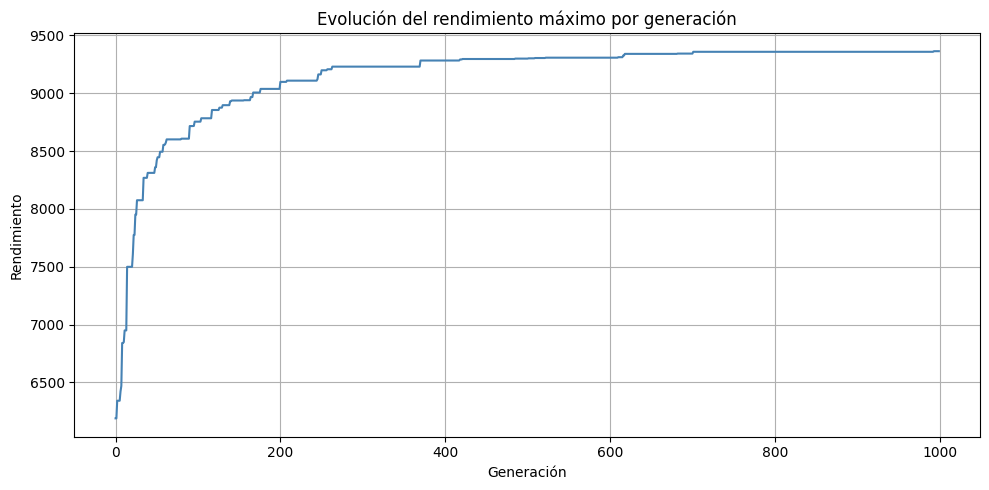

Gráfica guardada como 'grafica_rendimiento.png'
[0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 4, 0, 0, 0, 0, 3, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 3, 0, 0, 0, 0, 9, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 0, 0, 0, 0, 7, 0, 0, 0, 0, 10, 0, 0, 0, 2, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 6, 4, 0] 49945.58511292857 9362.77341236183
Capital invertido: 49945.58511292857
Rendimiento: 9362.77341236183


In [4]:
from random import random, randint, sample
from collections import namedtuple
import matplotlib.pyplot as plt

# Calcula el capital invertido por un individuo
def capitalInvertido(individuo):
    return sum(map(lambda x,y: x*y.precio, individuo, inversiones))

# Calcula el rendimiento obtenido por un individuo
def rendimiento(individuo):
    return sum(map(lambda x,y: x*y.precio*y.rendim,
                              individuo, inversiones))

# Si un individuo gasta más capital del disponible, se eliminan
# aleatoriamente inversiones hasta que se ajusta al capital
def ajustaCapital(individuo):
    ajustado = individuo[:]
    while capitalInvertido(ajustado) > capital:
        pos = randint(0, len(ajustado)-1)
        if ajustado[pos] > 0:
            ajustado[pos] -= 1

    return ajustado

# Crea un individuo al azar, en este caso una selección de
# inversiones que no excedan el capital disponible
def creaIndividuo(inversiones, capital):
    individuo = [0]*len(inversiones)

    while capitalInvertido(individuo) < capital:
        eleccion = randint(0, len(inversiones)-1)
        individuo[eleccion] += 1

    return ajustaCapital(individuo)

# Crea un nuevo individuo cruzando otros dos (cuyas posiciones se
# indican en el segundo parámetro)
def cruza(poblacion, posiciones):
    L = len(poblacion[0])

    # Toma los genes del primer progenitor y luego toma al azar
    # un segmento de entre 1 y L genes del segundo progenitor
    hijo   = poblacion[posiciones[0]][:]
    inicio = randint(0, L-1)
    fin    = randint(inicio+1, L)
    hijo[inicio:fin] = poblacion[posiciones[1]][inicio:fin]

    return ajustaCapital(hijo)

# Aplica mutaciones a un individuo según una tasa dada; garantiza
# que cumple las restricciones de capital e inversiones
def muta(individuo, tasaMutacion):
    mutado = []
    for i in range(len(individuo)):
        if random() > tasaMutacion:
            mutado.append(individuo[i])
        else:
            mutado.append(randint(0, inversiones[i].cantidad))

    return ajustaCapital(mutado)

# Hace evolucionar el sistema durante un número de generaciones
def evoluciona(poblacion, generaciones):

    # Ordena la población inicial por rendimiento producido
    poblacion.sort(key=lambda x: rendimiento(x))

    # Algunos valores útiles
    N            = len(poblacion)
    tasaMutacion = 0.01

    # Genera una lista del tipo [0,1,1,2,2,2,3,3,3,3,...] para
    # representar las probabilidades de reproducirse de cada
    # individuo (el primero 1 posibilidad, el segundo 2, etc.)
    reproduccion = [x for x in range(N) for y in range(x+1)]

    historial = []  # Para guardar el mejor rendimiento por generación

    for i in range(generaciones):
        # Se generan N-1 nuevos individuos cruzando los existentes
        # (sin que se repitan los padres)
        padres = sample(reproduccion, 2)
        while padres[0] == padres[1]:
            padres = sample(reproduccion, 2)
        hijos = [cruza(poblacion, padres) for x in range(N-1)]

        # Se aplican mutaciones con una cierta probabilidad
        hijos = [muta(x, tasaMutacion) for x in hijos]

        # Se añade el mejor individuo de la población anterior
        # (elitismo)
        hijos.append(poblacion[-1])
        poblacion = hijos

        # Se ordenan los individuos por rendimiento
        poblacion.sort(key=lambda x: rendimiento(x))

        historial.append(rendimiento(poblacion[-1]))

    # Grafica la evolución del mejor rendimiento por generación
    plt.figure(figsize=(10, 5))
    plt.plot(historial, color='steelblue')
    plt.title('Evolución del rendimiento máximo por generación')
    plt.xlabel('Generación')
    plt.ylabel('Rendimiento')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('grafica_rendimiento.png', dpi=150)
    plt.show()
    print("Gráfica guardada como 'grafica_rendimiento.png'")

    # Devuelve el mejor individuo encontrado
    return poblacion[-1]


# Declara una tupla con nombres para representar cada inversión
Inversion = namedtuple('Inversion', 'precio cantidad rendim')

numInver  = 100
maxPrecio = 1000
maxCant   = 10
maxRend   = 0.2

# Genera una lista de tuplas Inversion
inversiones = [Inversion(random()*maxPrecio, randint(1, maxCant),
                         random()*maxRend) for i in range(numInver)]
print(inversiones)

capital     = 50000
individuos  = 20
generaciones = 1000

poblacion = [creaIndividuo(inversiones, capital)
                           for i in range(individuos)]

# Nota: para simplificar el programa se accede a inversiones y
# capital de forma global (sólo se leen, no se modifican)

mejor = evoluciona(poblacion, generaciones)
print(mejor, capitalInvertido(mejor), rendimiento(mejor))

print("Capital invertido:", capitalInvertido(mejor))
print("Rendimiento:", rendimiento(mejor))

[2, 4, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 4, 0, 0, 0, 8, 0, 0, 0, 0, 9, 0, 0, 0, 0, 3, 0, 0, 0, 0, 3, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 4, 0, 1, 0, 0, 1, 6, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 4, 0, 0, 7, 0, 0]
Capital invertido: 49996.821789029535
Rendimiento: 8801.704046517822


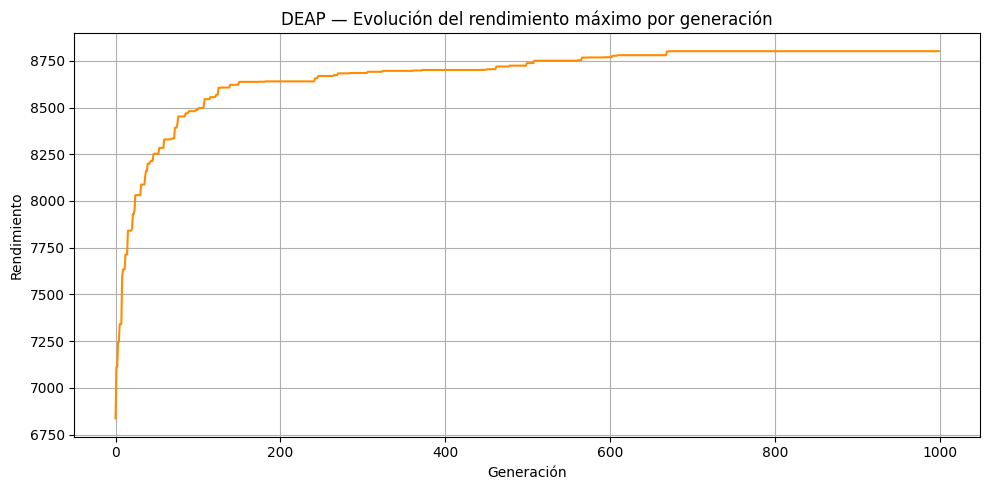

Gráfica guardada como 'grafica_rendimiento_deap.png'


In [3]:
from random import random, randint
from collections import namedtuple
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms


# DATOS DEL PROBLEMA (mismos que la versión 1)

Inversion = namedtuple('Inversion', 'precio cantidad rendim')

numInver  = 100
maxPrecio = 1000
maxCant   = 10
maxRend   = 0.2

inversiones = [Inversion(random()*maxPrecio, randint(1, maxCant),
                         random()*maxRend) for i in range(numInver)]

capital      = 50000
individuos   = 20
generaciones = 1000


# FUNCIONES AUXILIARES (mismas que la versión 1)

def capitalInvertido(individuo):
    return sum(x * y.precio for x, y in zip(individuo, inversiones))

def ajustaCapital(individuo):
    while capitalInvertido(individuo) > capital:
        pos = randint(0, len(individuo)-1)
        if individuo[pos] > 0:
            individuo[pos] -= 1
    return individuo


# DIFERENCIA 1 — FUNCIÓN OBJETIVO (FITNESS)
# En la versión del libro se calcula con rendimiento()
# y se ordena la población manualmente.
# Con DEAP se define como una función que devuelve
# una TUPLA, y el framework se encarga de comparar.

def funcionObjetivo(individuo):
    if capitalInvertido(individuo) > capital:
        return (0.0,)   # penalización si excede el capital
    return (sum(x * y.precio * y.rendim for x, y in zip(individuo, inversiones)),)


# DIFERENCIA 2 — CONFIGURACIÓN CON DEAP
# En la versión del libro cada operador es una
# función definida a mano (cruza, muta, etc.).
# Con DEAP se registran en un Toolbox.


# Tipo de fitness: maximizar (weights positivo)
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
# Individuo: lista de enteros con el fitness adjunto
creator.create("Individuo", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Genera un gen aleatorio (cuántos bonos del tipo i comprar)
def genAleatorio(i):
    return randint(0, inversiones[i].cantidad)

# Crea un individuo como lista de genes y lo ajusta al capital
def creaIndividuo():
    ind = creator.Individuo(genAleatorio(i) for i in range(numInver))
    ajustaCapital(ind)
    return ind

toolbox.register("individual", creaIndividuo)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# DIFERENCIA 2a — Función objetivo
toolbox.register("evaluate", funcionObjetivo)

# DIFERENCIA 2b — Selección
# Libro: selección proporcional manual con lista de probabilidades
# DEAP:  selección por torneo (tournament selection)
toolbox.register("select", tools.selTournament, tournsize=3)

# DIFERENCIA 2c — Cruza
# Libro: cruza de un punto con segmento aleatorio + ajustaCapital
# DEAP:  cruza de dos puntos estándar (cxTwoPoint)
def cruzaDeap(ind1, ind2):
    tools.cxTwoPoint(ind1, ind2)
    ajustaCapital(ind1)
    ajustaCapital(ind2)
    return ind1, ind2

toolbox.register("mate", cruzaDeap)

# DIFERENCIA 2d — Mutación
# Libro: reemplaza genes al azar según tasaMutacion
# DEAP:  mutación uniforme de enteros (mutUniformInt)
def mutaDeap(individuo, tasaMutacion):
    for i in range(len(individuo)):
        if random() < tasaMutacion:
            individuo[i] = randint(0, inversiones[i].cantidad)
    ajustaCapital(individuo)
    return (individuo,)

toolbox.register("mutate", mutaDeap, tasaMutacion=0.01)


# EJECUCIÓN DEL ALGORITMO CON DEAP

poblacion = toolbox.population(n=individuos)

# Estadísticas para registrar el mejor fitness por generación
stats = tools.Statistics(key=lambda ind: ind.fitness.values[0])
stats.register("max", max)

historial = []

# eaSimple: algoritmo genético simple incluido en DEAP
# Equivale al bucle evoluciona() de la versión del libro
for gen in range(generaciones):
    # Selección
    seleccionados = toolbox.select(poblacion, len(poblacion))
    hijos = list(map(toolbox.clone, seleccionados))

    # Cruza
    for hijo1, hijo2 in zip(hijos[::2], hijos[1::2]):
        if random() < 0.7:
            toolbox.mate(hijo1, hijo2)
            del hijo1.fitness.values
            del hijo2.fitness.values

    # Mutación
    for mutante in hijos:
        toolbox.mutate(mutante)
        del mutante.fitness.values

    # Evaluar los que no tienen fitness
    invalidos = [ind for ind in hijos if not ind.fitness.valid]
    for ind in invalidos:
        ind.fitness.values = toolbox.evaluate(ind)

    # Elitismo: conservar el mejor de la generación anterior
    mejor_anterior = tools.selBest(poblacion, 1)[0]
    hijos[-1] = toolbox.clone(mejor_anterior)
    hijos[-1].fitness.values = toolbox.evaluate(hijos[-1])

    poblacion = hijos
    historial.append(tools.selBest(poblacion, 1)[0].fitness.values[0])


# RESULTADOS

mejor = tools.selBest(poblacion, 1)[0]
print(mejor)
print("Capital invertido:", capitalInvertido(mejor))
print("Rendimiento:", mejor.fitness.values[0])

# Gráfica
plt.figure(figsize=(10, 5))
plt.plot(historial, color='darkorange')
plt.title('DEAP — Evolución del rendimiento máximo por generación')
plt.xlabel('Generación')
plt.ylabel('Rendimiento')
plt.grid(True)
plt.tight_layout()
plt.savefig('grafica_rendimiento_deap.png', dpi=150)
plt.show()
print("Gráfica guardada como 'grafica_rendimiento_deap.png'")

# Comparación: Algoritmo Genético del Asesor de Inversiones

## 1. Diferencias en la Función Objetivo

- **Libro:** `rendimiento()` suma directamente `cantidad * precio * rendimiento` y devuelve un número.
- **DEAP:** `funcionObjetivo()` hace el mismo cálculo pero devuelve una tupla y penaliza con `(0.0,)` si se excede el capital.

-

## 2. Diferencias en el Fitness

- **Libro:** No existe clase de fitness. El rendimiento se calcula con `rendimiento()` y los individuos se ordenan con `sort()` el mejor siempre queda en `poblacion[-1]`.
- **DEAP:** Se define `creator.FitnessMax` con `weights=(1.0,)` para maximizar. El fitness se adjunta a cada individuo y DEAP lo gestiona automáticamente.



## 3. Diferencias en Selección, Cruza y Mutación

**Selección**
- **Libro:** Proporcional manual — lista `[0,1,1,2,2,2,...]` donde los mejores tienen más probabilidad de ser elegidos.
- **DEAP:** Torneo — se forman grupos de 3 individuos y el de mayor fitness de cada grupo pasa a la siguiente generación.

**Cruza**
- **Libro:** Se toma un segmento aleatorio entre un punto de inicio y fin del segundo padre y se inserta en el hijo.
- **DEAP:** `cxTwoPoint` — cruza estándar de dos puntos incluida en la librería.

**Mutación**
- **Libro:** Recorre cada gen y si `random() > tasaMutacion` lo reemplaza por un valor aleatorio válido.
- **DEAP:** Mismo criterio pero usando `random() < tasaMutacion` como condición, consistente con la convención estándar.



## 4. Resultados Obtenidos

| | Versión del Libro | Versión DEAP |
|---|---|---|
| **Capital invertido** | $49,945.58 | $49,996.82 |
| **Rendimiento final** | **$9,362.77** | $8,801.70 |

- Ambas curvas suben rápido al inicio y se estabilizan después de ~200 generaciones.
- La versión del libro obtuvo mayor rendimiento, probablemente porque su selección proporcional presiona más hacia los mejores individuos desde el inicio.
- Los resultados varían en cada ejecución porque las inversiones se generan aleatoriamente.